## Validate 10MW turbine interpolations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wrf_io import postproc
from MITRotor import IEA10MW, BEMGeometry

In [3]:
blue   = sns.color_palette("tab10")[0]
orange = sns.color_palette("tab10")[1]

In [4]:
fontsize = 20
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 
plt.rcParams['figure.dpi']      = 300

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [5]:
rotor = IEA10MW()
geom  = BEMGeometry(Nr=26,Ntheta=158,R=rotor.R, Rhub=rotor.hub_radius)


In [6]:
# r/R from WRF
r = np.array([4.2887516E-02,8.0421336E-02,1.1795520E-01,1.5548900E-01,1.9302280E-01,2.3055660E-01,2.6809050E-01,3.0562430E-01,3.4315810E-01,3.8069190E-01,4.1822580E-01,4.5575960E-01,4.9329350E-01,5.3082730E-01,5.6836120E-01,6.0589510E-01,6.4342890E-01,6.8096280E-01,7.1849670E-01,7.5603050E-01,7.9356440E-01,8.3109830E-01,8.6863210E-01,9.0616600E-01,9.4369980E-01,9.8123370E-01])

In [7]:
# Airfoil ID at each r/R from WRF
airfoil_ID = np.array([1,1,1,2,2,2,3,3,3,3,4,4,4,4,5,5,5,6,6,6,6,6,7,7,7,7])

In [8]:
# Verify MITRotor and WRF compute the same airfoil ID at each r/R
rotor.airfoil_func.airfoil_id_from_interp(r) == airfoil_ID

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

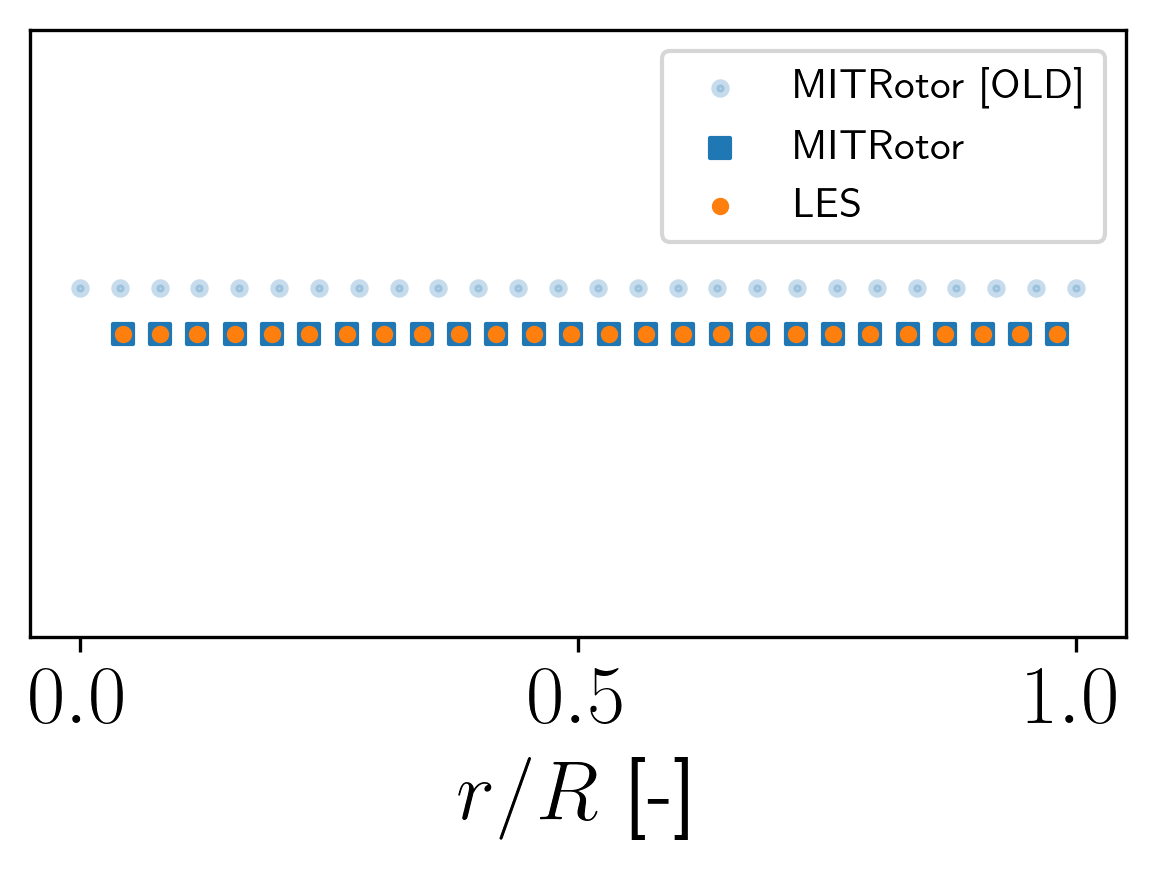

In [21]:
fig, ax = plt.subplots(figsize=(4, 3))


ax.scatter(np.linspace(0,1,26),0.15*np.ones_like(r), 15,zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.',label='MITRotor [OLD]')
ax.scatter(geom.mu,0*np.ones_like(r),25,marker='s', color=blue,label='MITRotor')
ax.scatter(r,0*np.ones_like(r),10,marker='o', color=orange,label='LES')

ax.set_yticks([])

ax.set_ylim([-1,1])
ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
# ax.set_ylabel('Airfoil index',fontsize=fontsize)
ax.legend()
plt.tight_layout()
plt.show()

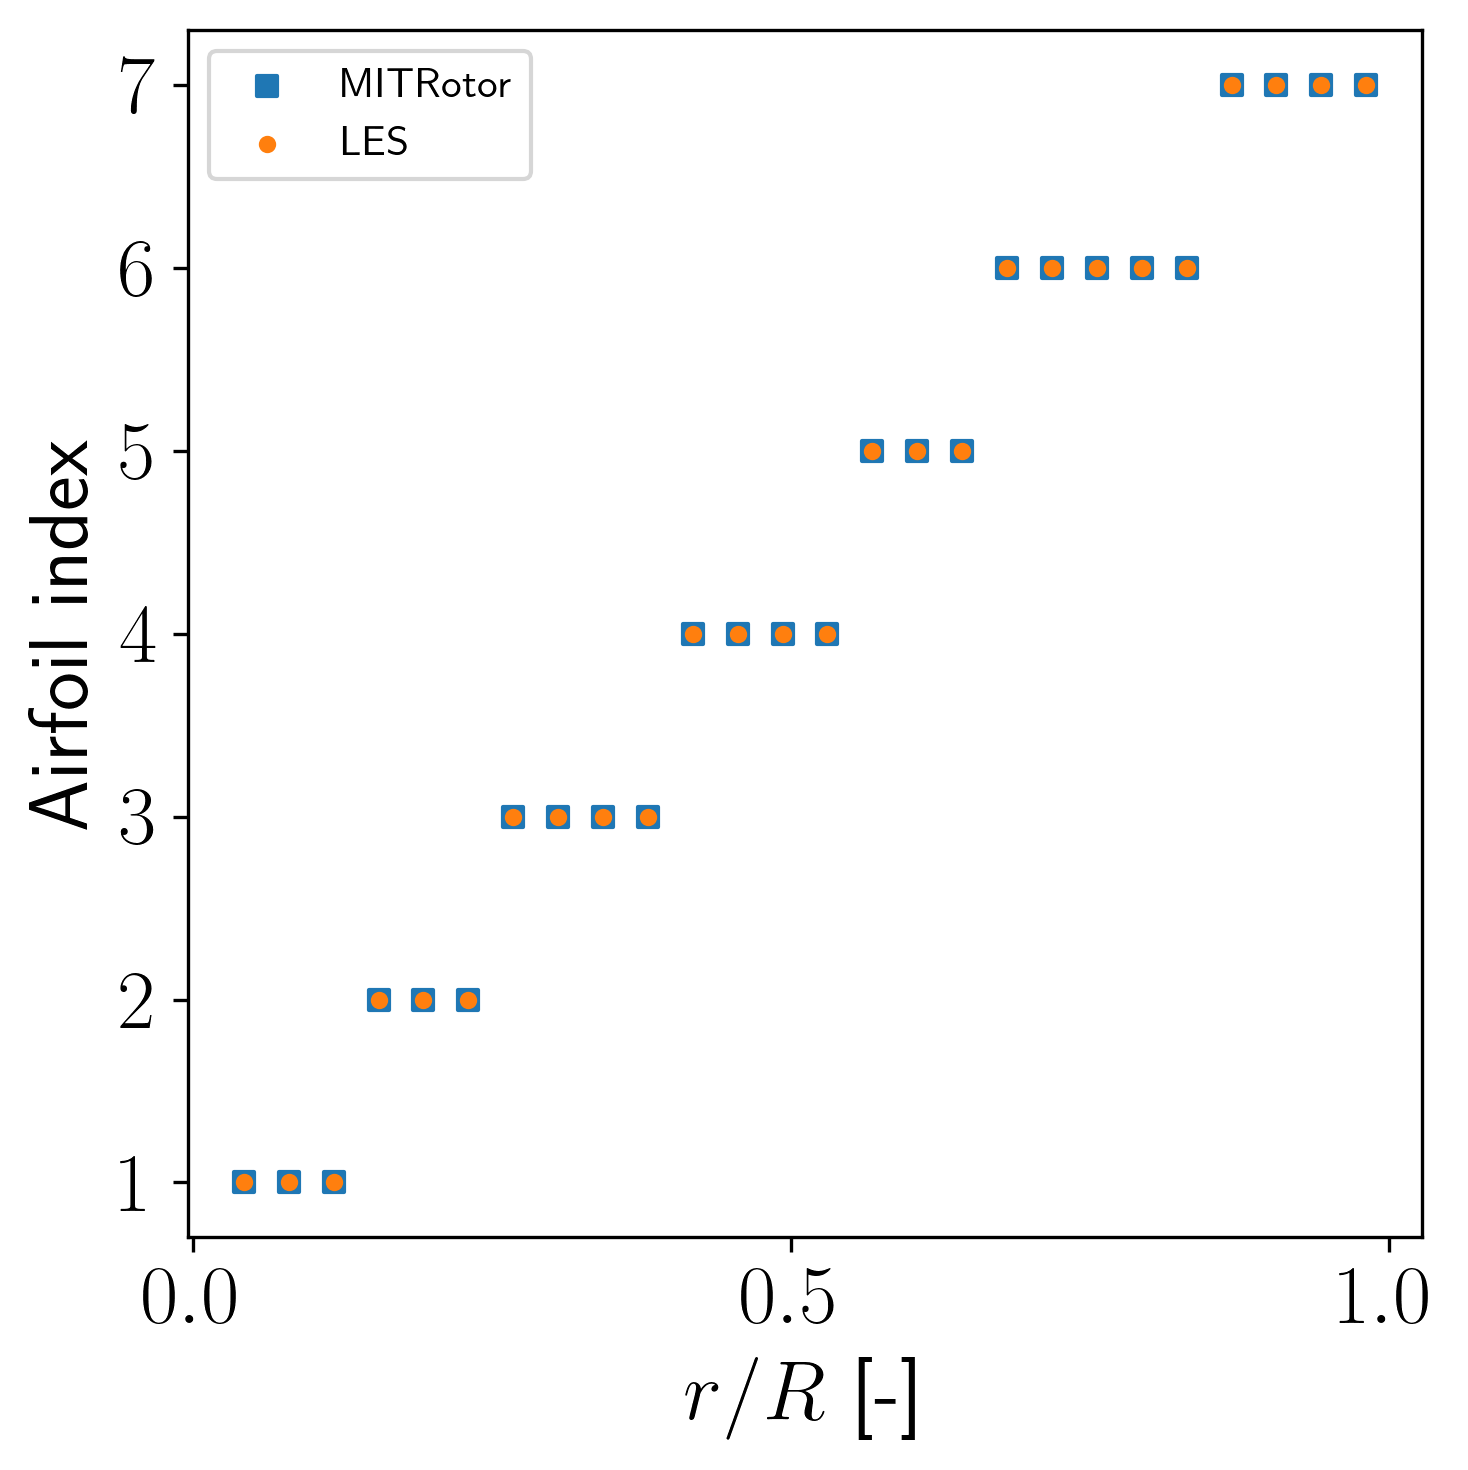

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(r,rotor.airfoil_func.airfoil_id_from_interp(r),25,marker='s', color=blue,label='MITRotor')
ax.scatter(r,airfoil_ID,10,marker='o', color=orange,label='LES')

unique_ids = np.unique(airfoil_ID)
ax.set_yticks(unique_ids)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Airfoil index',fontsize=fontsize)
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# airfoil names
airfoil_names = np.array(['cylinder', 'cylinder', 'FFA-W3-360', 'FFA-W3-330blend', 'FFA-W3-301', 'FFA-W3-270blend', 'FFA-W3-241', 'FFA-W3-211'])
airfoil_names

array(['cylinder', 'cylinder', 'FFA-W3-360', 'FFA-W3-330blend',
       'FFA-W3-301', 'FFA-W3-270blend', 'FFA-W3-241', 'FFA-W3-211'],
      dtype='<U15')

In [12]:
airfoil_mu = np.array([0.0241206,  0.0338794,  0.21441709, 0.26028342, 0.5071809,  0.59501005, 0.69259799, 1.0])
airfoil_mu

array([0.0241206 , 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ])

In [13]:
airfoil_r = airfoil_mu * rotor.R
airfoil_r

array([ 2.3999997 ,  3.3710003 , 21.33450046, 25.89820029, 50.46449955,
       59.20349997, 68.91350001, 99.5       ])

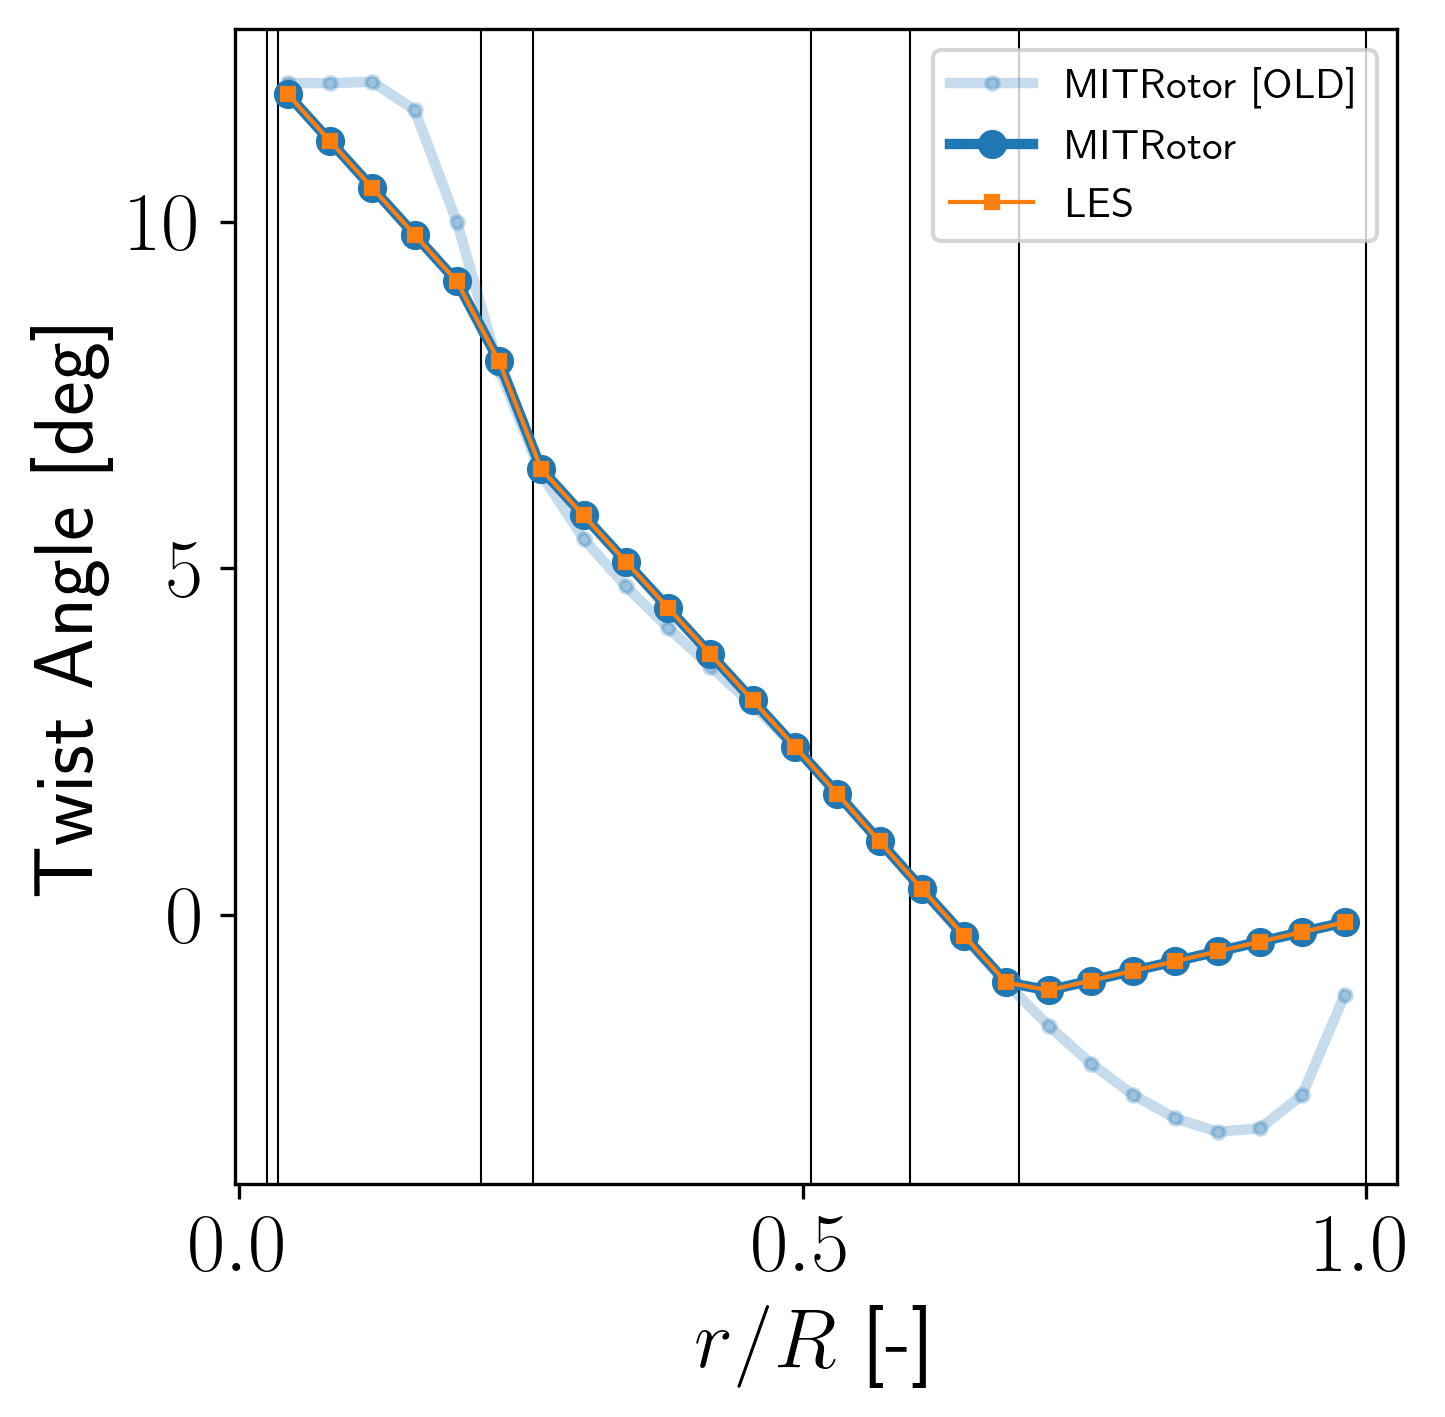

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r, np.rad2deg(rotor.twist_func_old(r)), zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r, np.rad2deg(rotor.twist_func(r)), zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r, [11.83793000,11.16304000,10.48815000,9.81326400,9.13837600,7.98429600,6.42827500,5.76149900,5.09472300,4.42794700,3.76117000,3.09439300,2.42761700,1.74792900,1.06066300,0.37665220,-0.29939410,-0.97544040,-1.08840600,-0.94824530,-0.80808410,-0.66792290,-0.52776180,-0.38760060,-0.24743940,-0.10727820],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Twist Angle [deg]',fontsize=fontsize)
ax.legend()

plt.show()

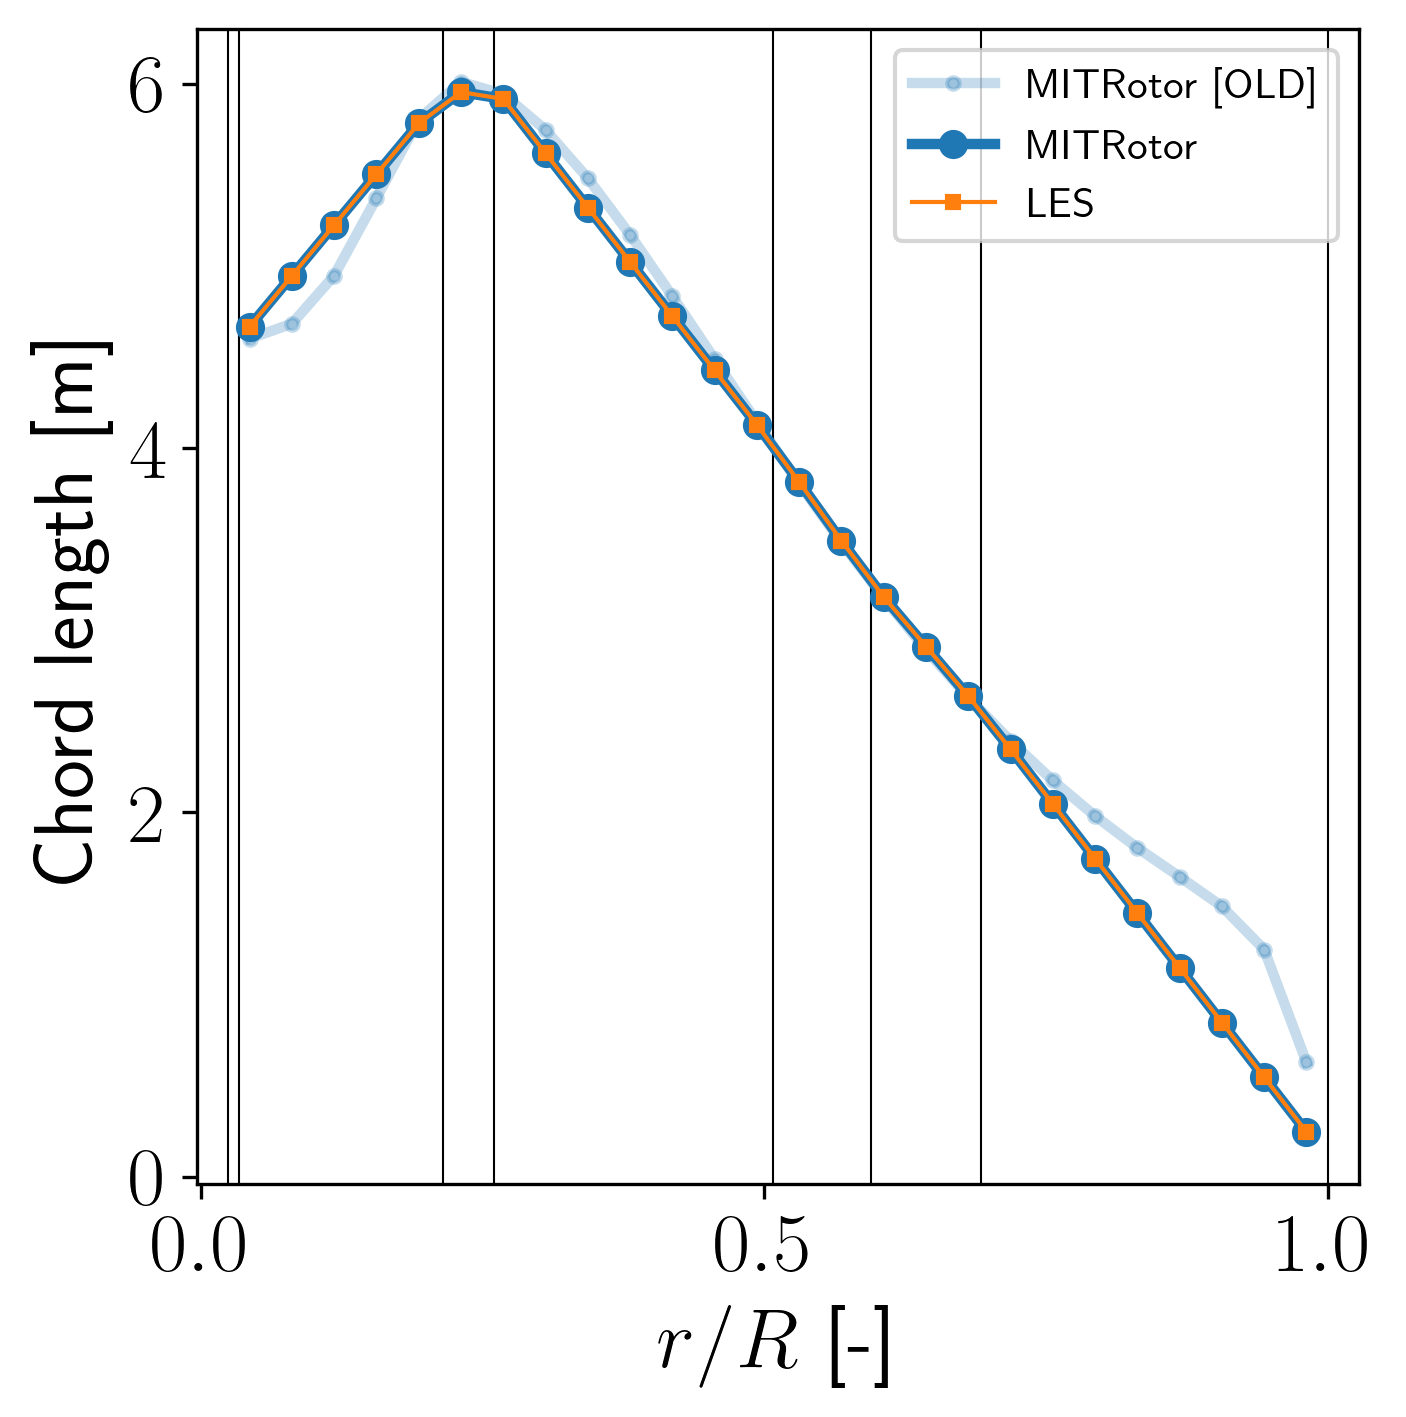

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r, rotor.chord_func_old(r), zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r,rotor.chord_func(r), zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[4.6676990,4.9464440,5.2251880,5.5039330,5.7826780,5.9548990,5.9173600,5.6191650,5.3209710,5.0227760,4.7245810,4.4263860,4.1281910,3.8143440,3.4913100,3.1830230,2.9108200,2.6386170,2.3471500,2.0470230,1.7468950,1.4467680,1.1466410,0.8465134,0.5463862,0.2462587],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('Chord length [m]',fontsize=fontsize)
ax.legend()

In [16]:
# Evaluate CL and CD in MITRotor
Cl, Cd = rotor.clcd(r, np.deg2rad(np.array([54.871,40.982,31.121,22.373,15.421,11.362,9.624,8.214,7.326,6.793,6.546,6.372,6.259,6.309,6.496,6.711,6.948,7.292,7.216,6.991,6.813,6.658,6.526,6.404,6.296,6.199])))

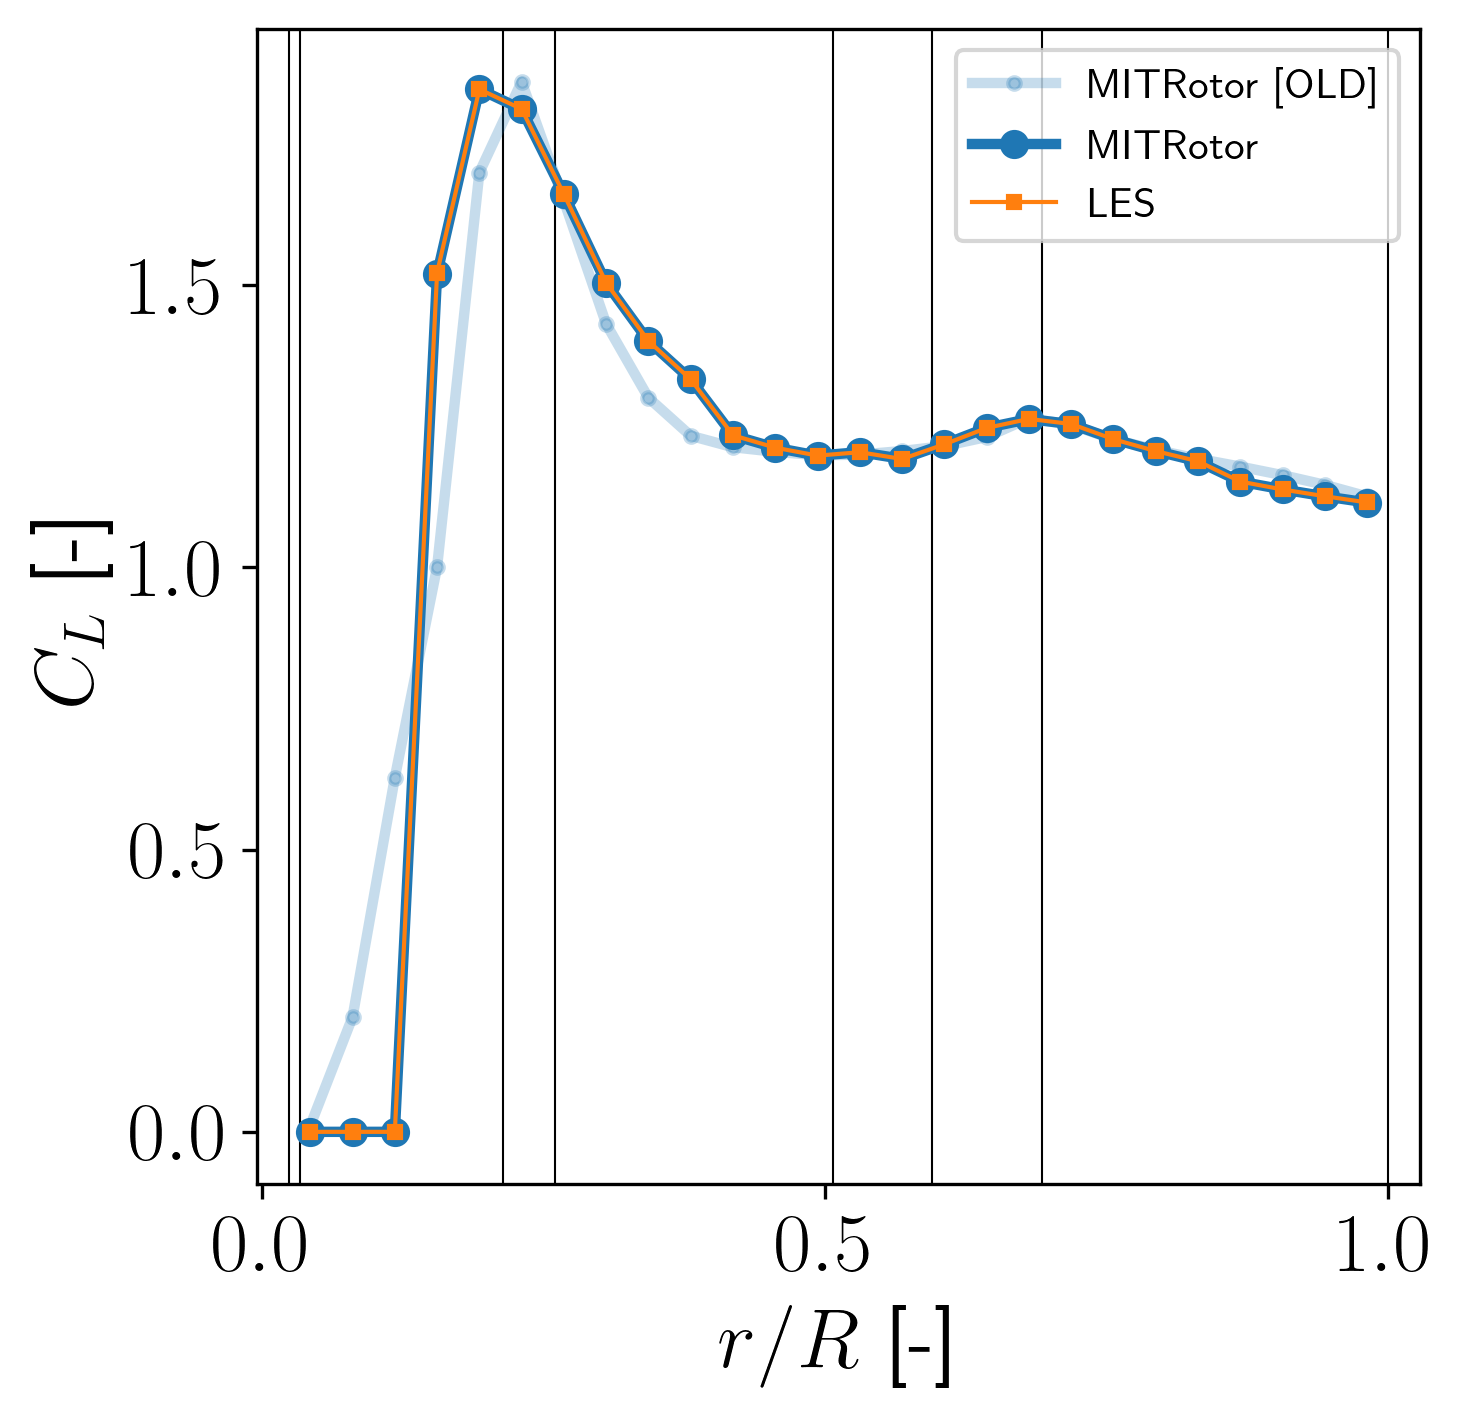

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r,[0.01095271, 0.20342758, 0.62749477, 1.0009184 , 1.69951309,1.86015423, 1.64959366, 1.43120665, 1.30036008, 1.23309482,1.21284996, 1.204737  , 1.19872911, 1.19966009, 1.20615876,1.21491161, 1.23103988, 1.2641205 , 1.25246604, 1.22690294,1.20815039, 1.19248427, 1.17848404, 1.16337809, 1.14623213,1.12566598], zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')
ax.plot(r,Cl, zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[0.0000,0.0000,0.0000,1.5220,1.8470,1.8120,1.6610,1.5040,1.4010,1.3330,1.2340,1.2120,1.1980,1.2040,1.1920,1.2180,1.2470,1.2630,1.2540,1.2270,1.2060,1.1880,1.1520,1.1380,1.1260,1.1150],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('$C_L$ [-]',fontsize=fontsize)
ax.legend()

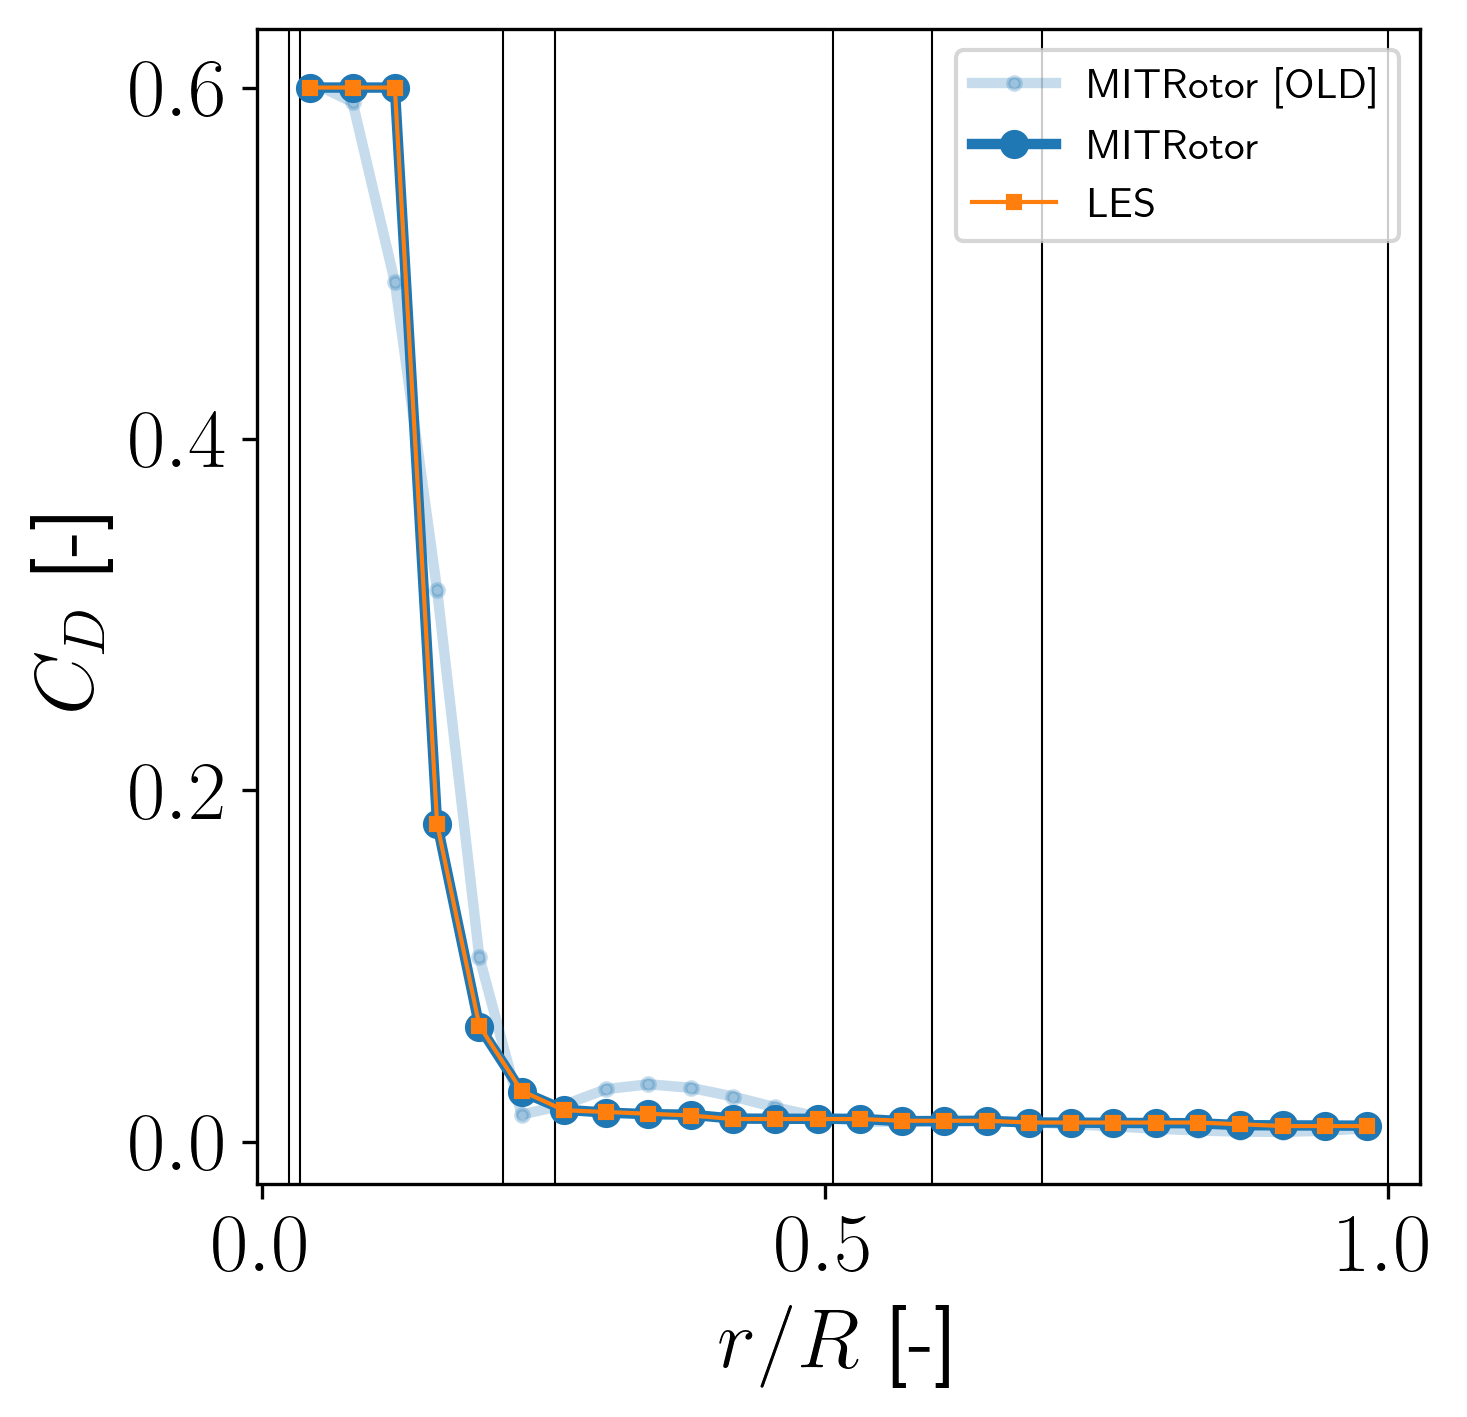

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(r,[0.60325562, 0.59173399, 0.48942205, 0.31402426, 0.10496567,0.0155413 , 0.02095849, 0.03001945, 0.03277364, 0.03077614,0.02579759, 0.01965745, 0.01431438, 0.01164329, 0.01138291,0.0117508 , 0.01164562, 0.01120058, 0.01012304, 0.00878542,0.00752157, 0.00647795, 0.00581934, 0.00570096, 0.00629232,0.00776003], zorder=2, alpha=0.25, color=blue, linewidth=2.5, marker='.', markersize=6, label='MITRotor [OLD]')

ax.plot(r,Cd, zorder=3, color=blue, linewidth=2.5, marker='o', markersize=6, label='MITRotor')
ax.plot(r,[0.6000,0.6000,0.6000,0.1810,0.0660,0.0290,0.0180,0.0170,0.0160,0.0150,0.0130,0.0130,0.0130,0.0130,0.0120,0.0120,0.0120,0.0110,0.0110,0.0110,0.0110,0.0110,0.0100,0.0090,0.0090,0.0090],
        zorder=4, marker='s', color=orange, linewidth=1, markersize=3, label='LES')

for x in airfoil_mu:
    ax.axvline(x, color='k', linewidth=0.5,zorder=1)

ax.set_xlabel('$r / R$ [-]',fontsize=fontsize)
ax.set_ylabel('$C_D$ [-]',fontsize=fontsize)
ax.legend()